--- SIR Simulation Parameters ---
Total Population Scale: 100000
Basic Reproduction Number (R0 Metric): 3.50

--- Evaluated Forecasts ---
Peak Concurrent Infections: 35647 individuals
Peak Timeline Milestone: Day 31.7



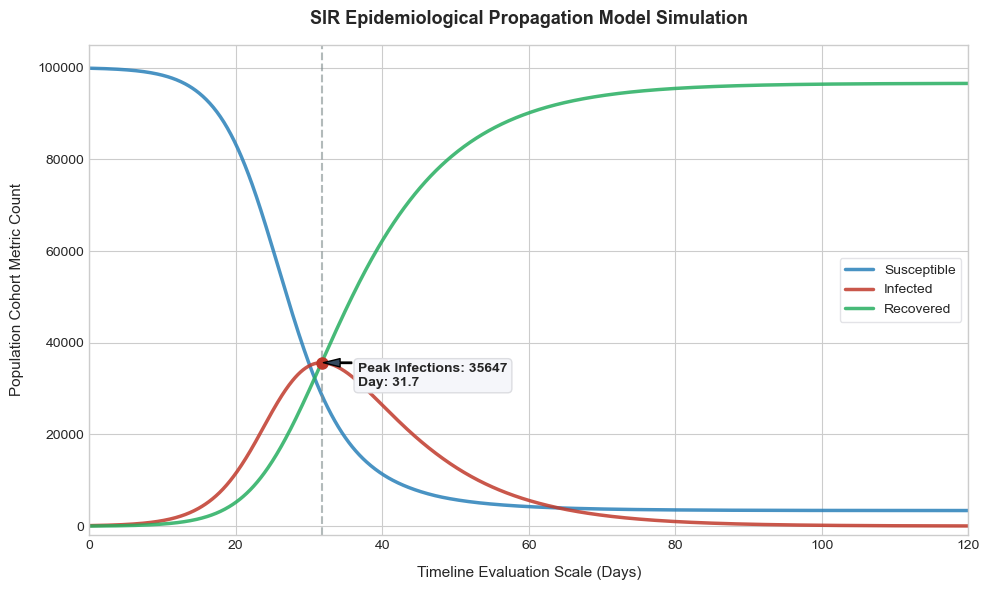

In [1]:
import numpy as np
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt

# ==========================================
# 1. DEFINE THE DIFFERENTIAL EQUATIONS
# ==========================================
def sir_deriv(t, y, N, beta, gamma):
    """
    Computes the derivatives for the SIR model at time t.
    y = [S, I, R] represents the current state of the cohorts.
    """
    S, I, R = y
    dSdt = -beta * S * I / N
    dIdt = (beta * S * I / N) - (gamma * I)
    dRdt = gamma * I
    return [dSdt, dIdt, dRdt]

# ==========================================
# 2. SIMULATION PARAMETERS & CONSTRAINTS
# ==========================================
N = 100000        # Total simulated population scale
I0 = 100          # Initial infected cohort size
R0 = 0            # Initial recovered cohort size
S0 = N - I0 - R0   # Initial susceptible population baseline

beta = 0.35       # Transmission rate (contact frequency framework)
gamma = 0.10      # Recovery rate (1 / days infectious)
r_zero = beta / gamma

print("--- SIR Simulation Parameters ---")
print(f"Total Population Scale: {N}")
print(f"Basic Reproduction Number (R0 Metric): {r_zero:.2f}\n")

# ==========================================
# 3. NUMERICAL INTEGRATION RUN (RK45)
# ==========================================
t_span = (0, 120)  # Evaluate across a 120-day duration window
t_eval = np.linspace(0, 120, 1000)
initial_state = [S0, I0, R0]

# Solve the initial value problem using Runge-Kutta 4th/5th-order accuracy
solution = solve_ivp(
    sir_deriv, 
    t_span, 
    initial_state, 
    args=(N, beta, gamma), 
    t_eval=t_eval,
    method='RK45'
)

S, I, R = solution.y
t = solution.t

# ==========================================
# 4. METRIC EXTRACTION & FORECASTS
# ==========================================
peak_infections = np.max(I)
peak_day = t[np.argmax(I)]

print("--- Evaluated Forecasts ---")
print(f"Peak Concurrent Infections: {int(peak_infections)} individuals")
print(f"Peak Timeline Milestone: Day {peak_day:.1f}\n")

# ==========================================
# 5. DATA VISUALIZATION LAYER
# ==========================================
# Apply clear visual framing styling
plt.style.use('seaborn-v0_8-whitegrid') if 'seaborn-v0_8-whitegrid' in plt.style.available else plt.grid(True)
plt.figure(figsize=(10, 6))

# Plot the three evaluation trend lines
plt.plot(t, S, color='#2980b9', linestyle='-', alpha=0.85, linewidth=2.5, label='Susceptible')
plt.plot(t, I, color='#c0392b', linestyle='-', alpha=0.85, linewidth=2.5, label='Infected')
plt.plot(t, R, color='#27ae60', linestyle='-', alpha=0.85, linewidth=2.5, label='Recovered')

# Highlight the peak coordinate with an analytical annotation marker
plt.axvline(x=peak_day, color='#7f8c8d', linestyle='--', alpha=0.6)
plt.plot(peak_day, peak_infections, marker='o', markersize=8, color='#c0392b')
plt.annotate(
    f"Peak Infections: {int(peak_infections)}\nDay: {peak_day:.1f}",
    xy=(peak_day, peak_infections),
    xytext=(peak_day + 5, peak_infections - 5000),
    arrowprops=dict(facecolor='#34495e', shrink=0.05, width=1, headwidth=6),
    fontsize=10,
    fontweight='bold',
    bbox=dict(boxstyle="round,pad=0.3", fc="#f5f6fa", ec="#dcdde1", lw=1)
)

# Axis polishing and labeling configurations
plt.title('SIR Epidemiological Propagation Model Simulation', fontsize=13, fontweight='bold', pad=15)
plt.xlabel('Timeline Evaluation Scale (Days)', fontsize=11, labelpad=10)
plt.ylabel('Population Cohort Metric Count', fontsize=11, labelpad=10)
plt.xlim(t_span)
plt.ylim(-2000, N + 5000)
plt.legend(loc='center right', frameon=True, facecolor='#ffffff', edgecolor='#dcdde1', fontsize=10)
plt.tight_layout()

# Render the layout graph output canvas
plt.show()